# Visualizing results

In [1]:
import os
import pandas as pd
import plotnine as pln

In [2]:
doubles = ['PABP_YEAST_Fields2013_doubles', 'parEparD_Laub2015_all', 'AAV2_CAPSD_Sinai', 'PESV_POLG_Tsuboyama', 'BP434_RPC1_Tsuboyama']

In [3]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/cellular/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/cellular/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# Viral x Cellular proteins

In [4]:
cols = ['R2_score_train', 'MAE_score_train', 'RMSE_score_train','rho_score_train',
       'R2_score_test', 'MAE_score_test', 'RMSE_score_test', 'rho_score_test', 'num_nonzero_coefs']

In [5]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res


lassocv = pd.DataFrame()
for model in ['esm2_650M', 'esmc_600M', 'esm2_3B_Sawhney', 'esm2_650M_CRVDB', 'esm2_650M_URVDB']:
    for source in ['viral', 'cellular']:
        for method in ['pool_split', 'site_split']:
            res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            
            lassocv = pd.concat([lassocv, res], ignore_index=True)

rename_map = {
    'esm2_650M':'ESM-2 650M',
    'esmc_600M':'ESM C 600M',
    'esm2_650M_CRVDB':'ESM-2-CRVDB', 
    'esm2_650M_URVDB':'ESM-2-URVDB', 
    'esm2_3B_Sawhney':'ESM-2 3B Sawhney',
    'pool_split':'Pooled Split',
    'site_split':'Site Split',
    }

lassocv.replace(rename_map, inplace=True)
lassocv = lassocv.groupby(['Model', 'Source', 'Dataset', 'Split'], as_index=False)[cols].mean()
lassocv

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs
0,ESM C 600M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.544940,0.502568,0.674223,0.763363,0.476794,0.532886,0.723885,0.730510,301.6
1,ESM C 600M,cellular,AMIE_PSEAE_Whitehead,Site Split,0.382721,0.598540,0.790733,0.630565,0.254229,0.631912,0.834631,0.507805,58.4
2,ESM C 600M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.473849,0.583160,0.724281,0.703427,0.420559,0.613820,0.765567,0.667434,335.6
3,ESM C 600M,cellular,B3VI55_LIPSTSTABLE,Site Split,0.319779,0.669790,0.824618,0.593023,0.236757,0.708520,0.872100,0.514334,54.4
4,ESM C 600M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.303514,0.633591,0.835410,0.527946,0.231265,0.664253,0.872660,0.464384,411.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,ESM-2-URVDB,viral,SARS2_RBD_binding_Starr,Site Split,0.313877,0.612924,0.821654,0.475606,0.071141,0.705108,0.949971,0.261448,58.0
736,ESM-2-URVDB,viral,SARS2_RBD_expression_Starr,Pooled Split,0.764292,0.379187,0.485522,0.859415,0.627369,0.478313,0.609208,0.777565,629.4
737,ESM-2-URVDB,viral,SARS2_RBD_expression_Starr,Site Split,0.174692,0.789631,0.902117,0.411556,0.091190,0.842584,0.969542,0.284565,24.6
738,ESM-2-URVDB,viral,SARS2_XBB15_RBD_Taylor,Pooled Split,0.750155,0.382870,0.501086,0.730970,0.584505,0.470403,0.635324,0.651170,521.6


In [6]:
res_esm2 = lassocv.query('Model == "ESM-2 650M"').copy()
res_esm2['Source'] = pd.Categorical(res_esm2['Source'], categories=['viral', 'cellular'])
res_esm2['prot_length'] = res_esm2['Dataset'].map(prot_lengths)
res_esm2

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,prot_length
296,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.593274,0.473718,0.637422,0.794904,0.486188,0.525113,0.717140,0.738094,444.8,346
297,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Site Split,0.374695,0.604338,0.795778,0.647042,0.231793,0.647925,0.845461,0.504309,79.6,346
298,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.556010,0.529118,0.665334,0.764524,0.468531,0.579832,0.733204,0.713379,590.4,439
299,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Site Split,0.362078,0.643427,0.798541,0.642935,0.243568,0.700345,0.868268,0.545077,89.6,439
300,ESM-2 650M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.360828,0.607812,0.800282,0.562654,0.256701,0.650875,0.857956,0.474479,533.0,439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,ESM-2 650M,viral,SARS2_RBD_binding_Starr,Site Split,0.238382,0.650661,0.870498,0.389841,0.033222,0.719386,0.968608,0.200680,34.4,1273
440,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Pooled Split,0.729695,0.409088,0.520078,0.843533,0.574433,0.506460,0.650963,0.751288,562.6,1273
441,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Site Split,0.120889,0.818213,0.930678,0.289695,0.034882,0.875149,0.999084,0.193756,16.4,1273
442,ESM-2 650M,viral,SARS2_XBB15_RBD_Taylor,Pooled Split,0.666417,0.440333,0.577750,0.693423,-0.196764,0.541360,1.001461,0.610699,454.0,201


In [ ]:
#res_esm2.to_csv('../experiments/compiled_results/res_lassoCV_esm2_650m_v03.csv')

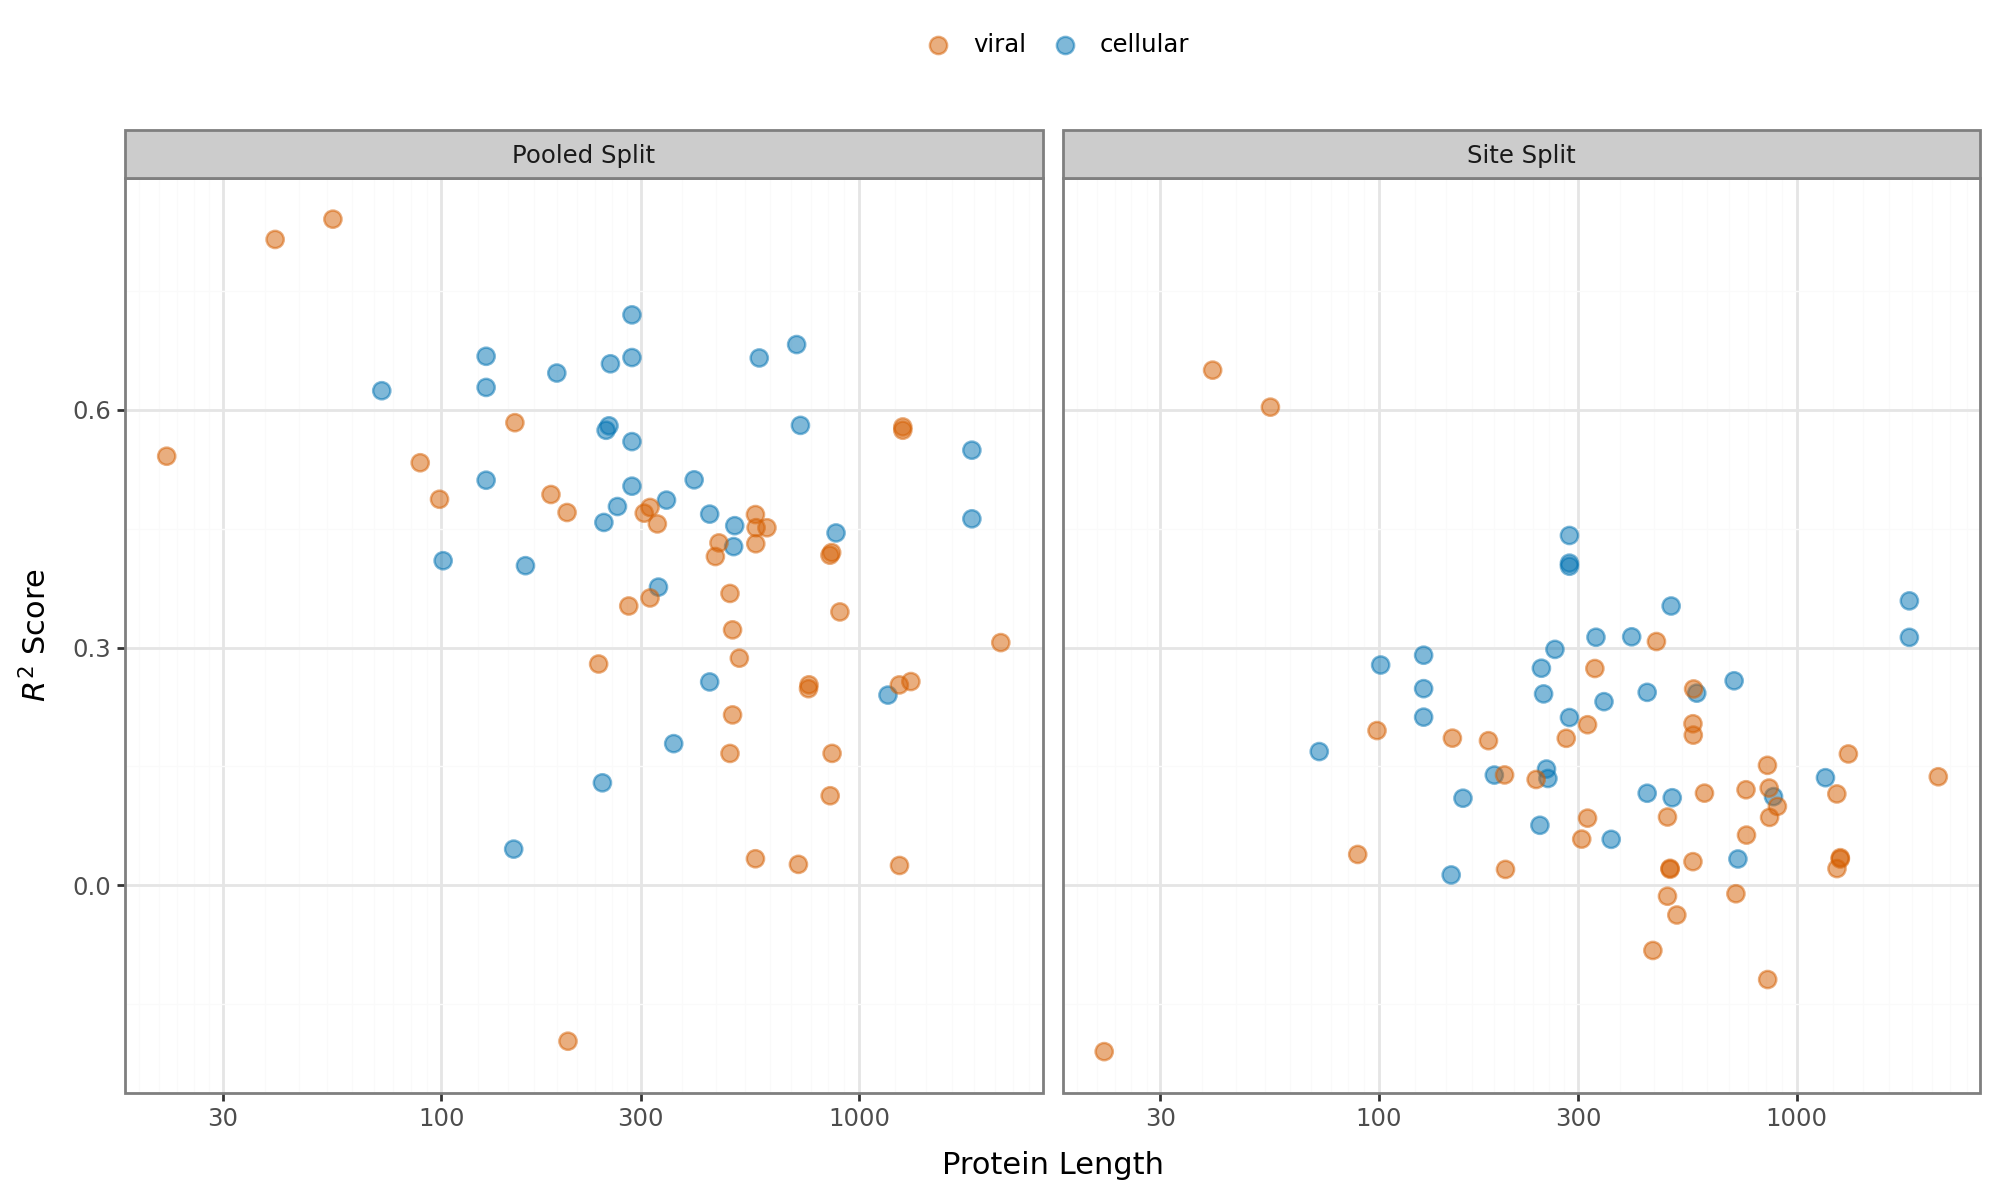

In [ ]:
plot = (
    pln.ggplot(res_esm2, pln.aes(x='prot_length', y='R2_score_test'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_wrap('Split')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score")
    + pln.theme_bw()
    + pln.theme(figure_size=(10, 6), legend_position='top',legend_title=pln.element_blank())

)
plot#.save(filename='../experiments/protein_length_vs_lassocv_r2_full.png', dpi=600)

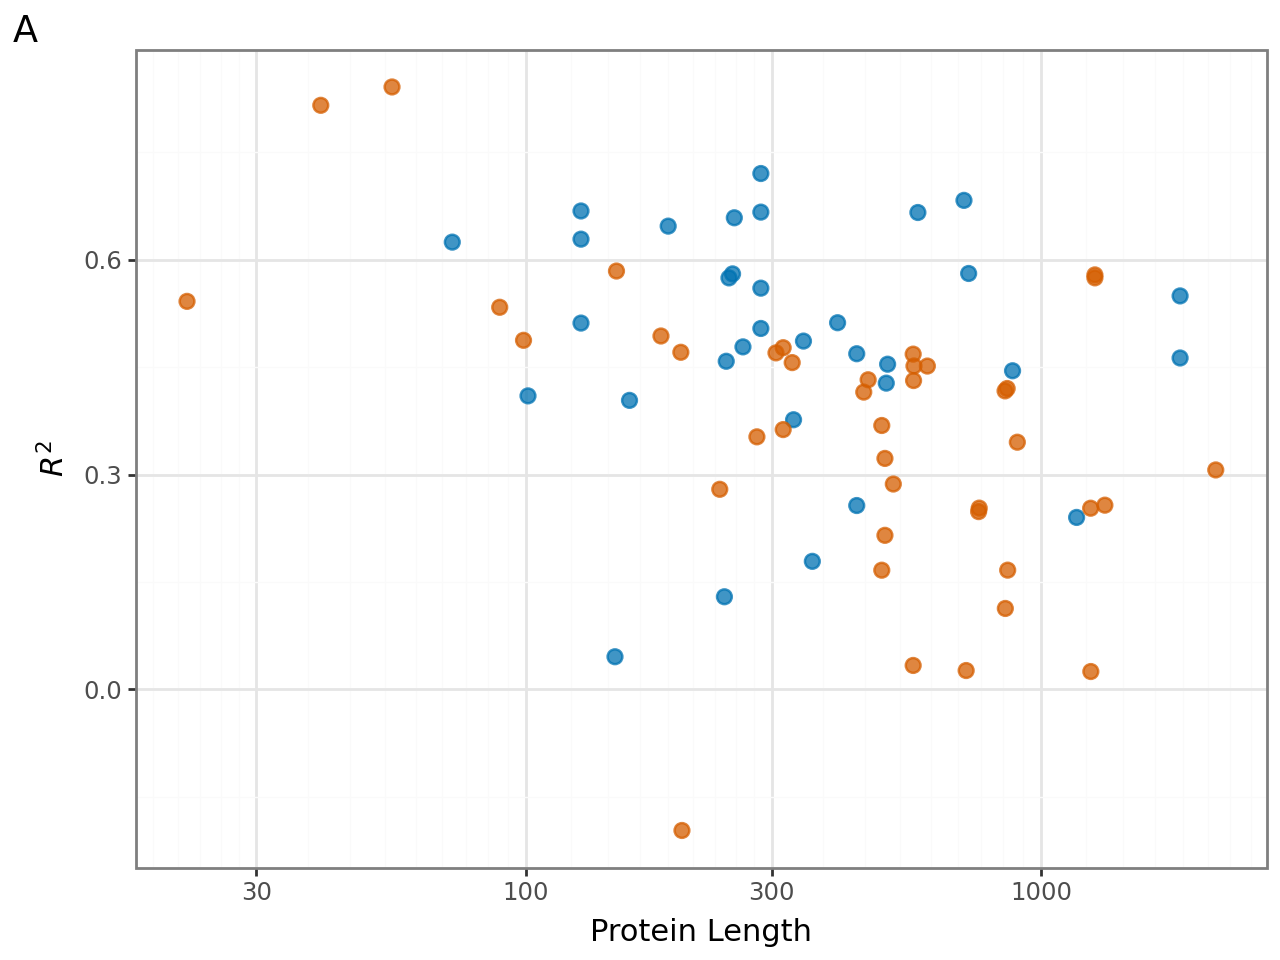

In [22]:
esm2_pooled = res_esm2.query('Split == "Pooled Split"')
p1 = (
    pln.ggplot(esm2_pooled, pln.aes(x='prot_length', y='R2_score_test'))
    + pln.geom_point(pln.aes(color='Source'), size=2.5, alpha=0.75)
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.scale_x_log10()
    + pln.labs(
        x="Protein Length", 
        y="$R^2$",
        tag="A")
    + pln.theme_bw()
    + pln.theme(
        #figure_size=(4.5, 3.5), 
        legend_position='none', legend_title=pln.element_blank())
)
p1

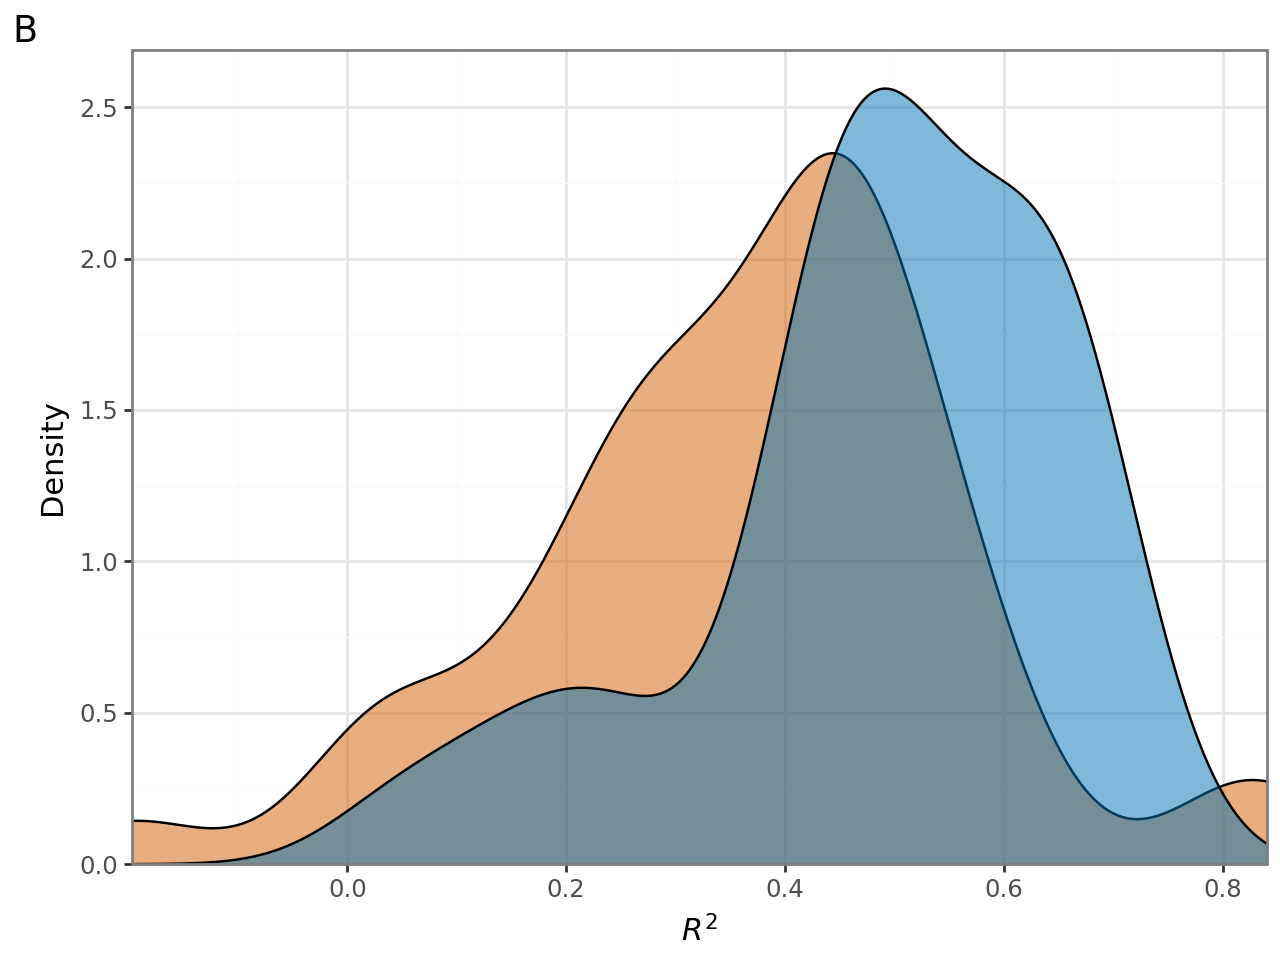

In [23]:
p2 = (
    pln.ggplot(esm2_pooled, pln.aes(x='R2_score_test'))
    + pln.geom_density(pln.aes(fill='Source'),  alpha=0.5)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.labs(
        x="$R^2$", 
        y="Density",
        tag="B")
    + pln.theme_bw()
    + pln.theme(
        #figure_size=(4.5, 3.5), 
        legend_position='none',
        legend_title=pln.element_blank())

)
p2

# Fine tuned models

In [8]:
res_full = lassocv
res_full ['Source'] = pd.Categorical(res_full['Source'], categories=['viral', 'cellular'])
res_full['Model'] = pd.Categorical(res_full['Model'], categories=['ESM-2 650M', 'ESM C 600M', 'ESM-2-CRVDB', 'ESM-2-URVDB', 'ESM-2 3B Sawhney'])
res_full['prot_length'] = res_full['Dataset'].map(prot_lengths)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 29 rows containing non-finite values.


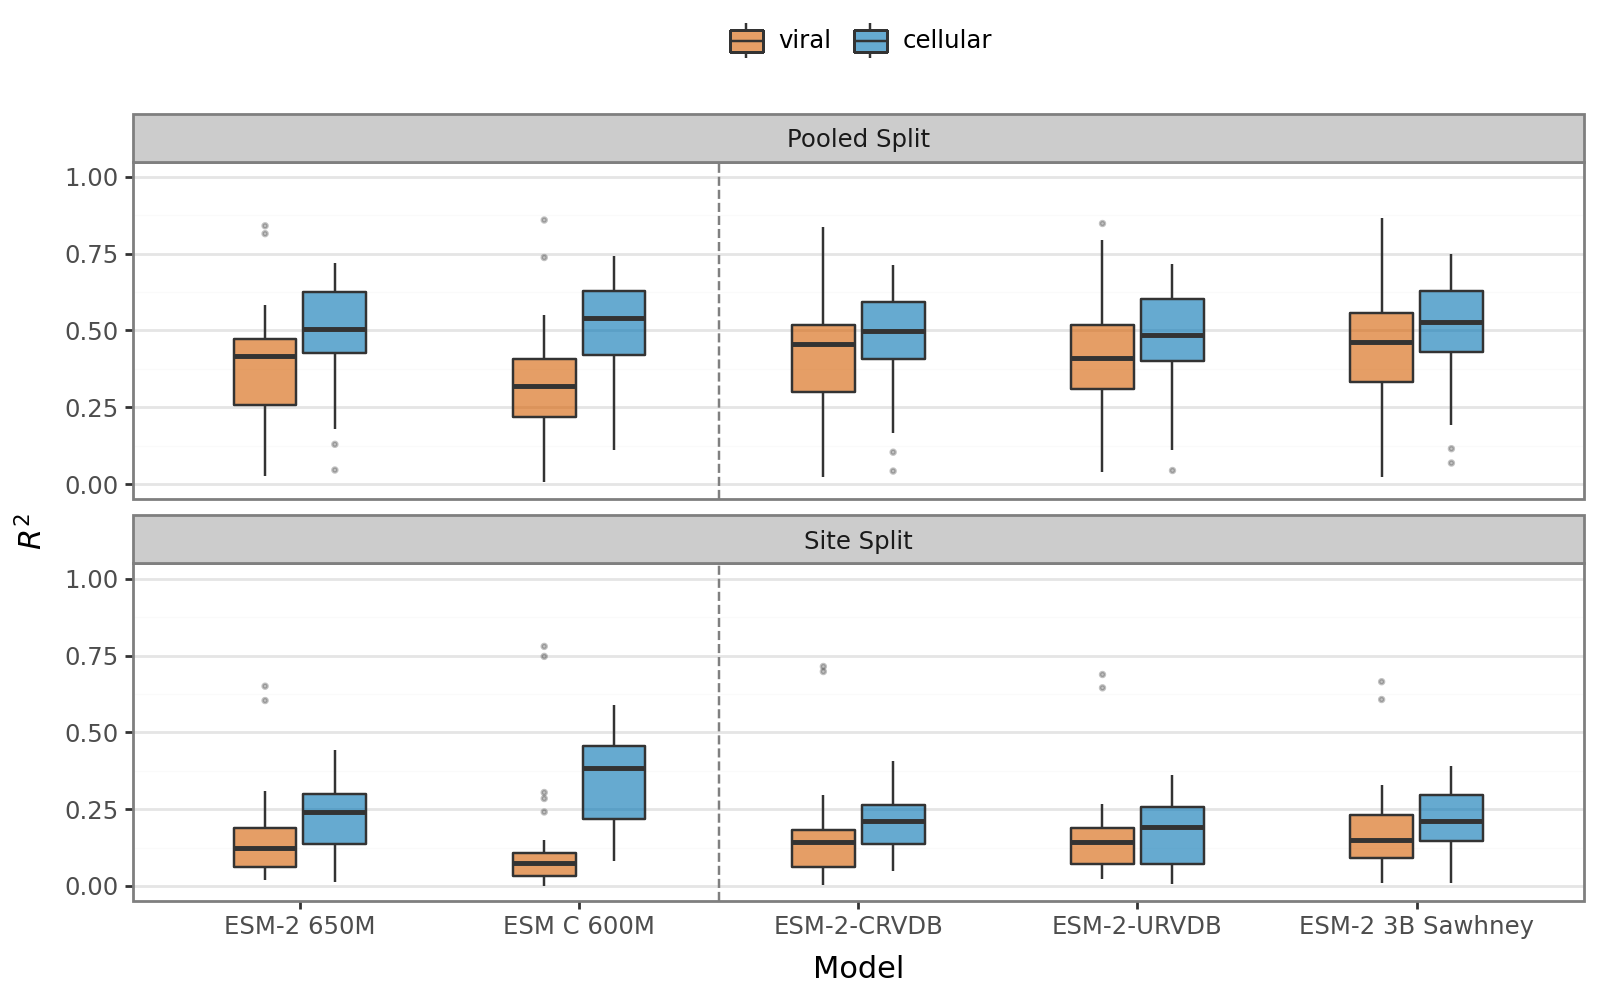

In [17]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Model', y='R2_score_test', fill='Source'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5, alpha=0.6)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_vline(xintercept=2.5, linetype='dashed', color='gray', size=0.5)
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.facet_wrap('~Split', nrow=2)
    + pln.ylim(0,1)
    + pln.theme(
        figure_size=(8, 5),
        panel_grid_major_x=pln.element_blank(),
        legend_position='top',
        legend_title=pln.element_blank(),
        
    )
)

plot#.save(filename='../experiments/lassoCV_finetuned_models.png', dpi=600)

In [24]:
res_full_pooled = res_full.query('Split == "Pooled Split"')
res_full_pooled

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,prot_length
0,ESM C 600M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.544940,0.502568,0.674223,0.763363,0.476794,0.532886,0.723885,0.730510,301.6,346
2,ESM C 600M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.473849,0.583160,0.724281,0.703427,0.420559,0.613820,0.765567,0.667434,335.6,439
4,ESM C 600M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.303514,0.633591,0.835410,0.527946,0.231265,0.664253,0.872660,0.464384,411.0,439
6,ESM C 600M,cellular,BG_STRSQ_hmmerbit,Pooled Split,0.586958,0.462587,0.641609,0.757999,0.539194,0.488546,0.682969,0.731760,118.6,501
8,ESM C 600M,cellular,BLAT_ECOLX_Ostermeier2014,Pooled Split,0.699910,0.431016,0.547510,0.864369,0.653427,0.461392,0.589177,0.837835,229.6,286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,ESM-2-URVDB,viral,SARS2_PLPRO_activity_Wu,Pooled Split,0.696530,0.442048,0.551820,0.802155,0.538994,0.535514,0.673979,0.716917,708.0,316
732,ESM-2-URVDB,viral,SARS2_PRD0038_RBD_Starr,Pooled Split,0.655388,0.435380,0.587529,0.636660,0.517681,0.482342,0.688893,0.579925,310.6,200
734,ESM-2-URVDB,viral,SARS2_RBD_binding_Starr,Pooled Split,0.769185,0.350650,0.477280,0.764901,0.656053,0.443538,0.599993,0.703929,622.2,1273
736,ESM-2-URVDB,viral,SARS2_RBD_expression_Starr,Pooled Split,0.764292,0.379187,0.485522,0.859415,0.627369,0.478313,0.609208,0.777565,629.4,1273


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 2 rows containing non-finite values.


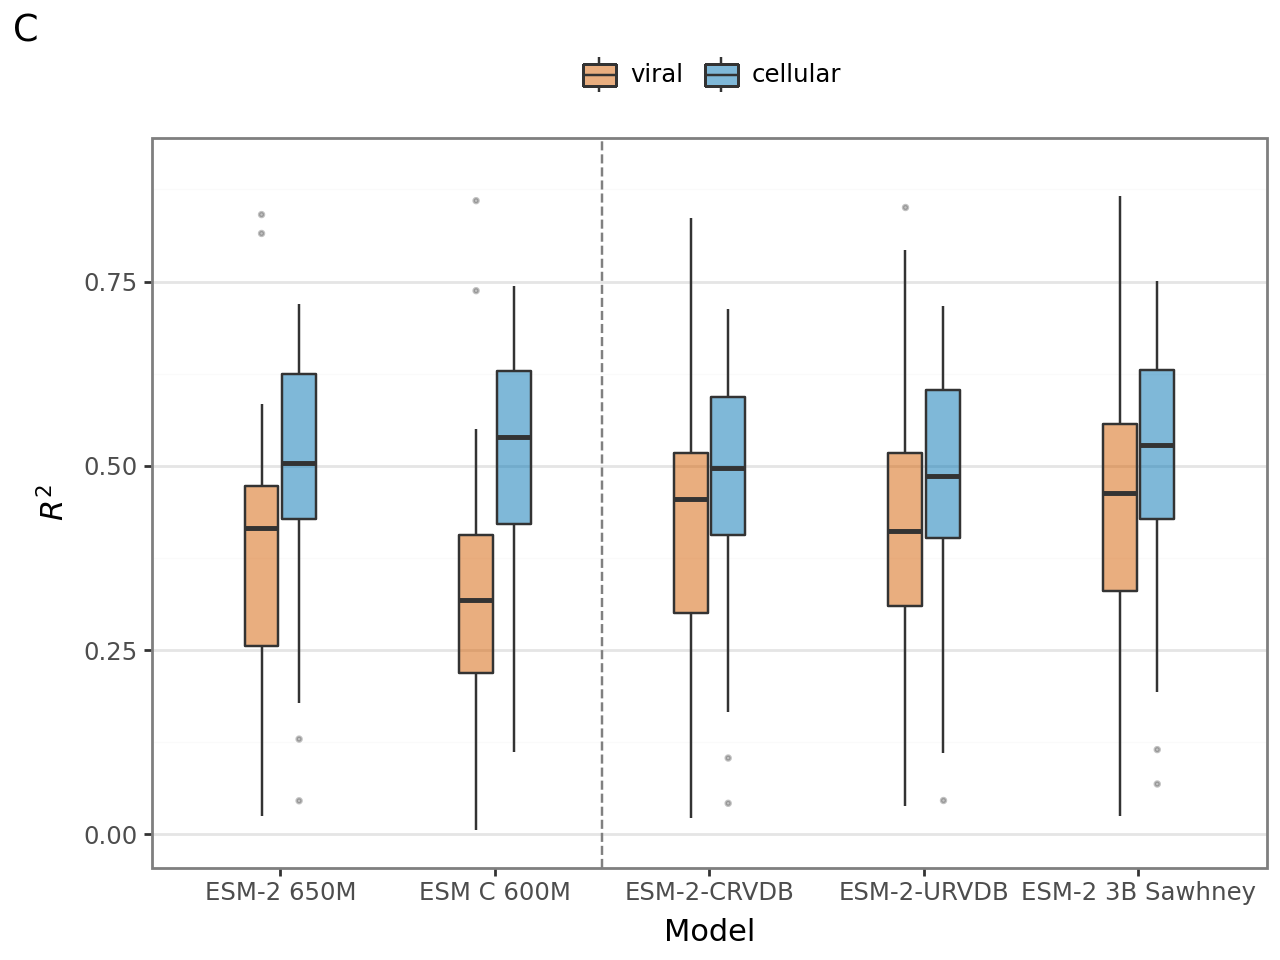

In [30]:
p3 = (
    pln.ggplot(res_full_pooled, pln.aes(x='Model', y='R2_score_test',fill='Source'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.35, alpha=0.5)
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_vline(xintercept=2.5, linetype='dashed', color='gray', size=0.5)
    + pln.labs(
        x='Model',
        y='$R^2$',
        tag='C'
    )
    + pln.theme_bw()
    + pln.ylim(0,.9)
    + pln.theme(
        legend_position='top',
        panel_grid_major_x=pln.element_blank(),
        legend_title=pln.element_blank(),
        legend_key=pln.element_rect(fill='white', color='black')
        )
)

p3

# Composed figure

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 2 rows containing non-finite values.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 2 rows containing non-finite values.


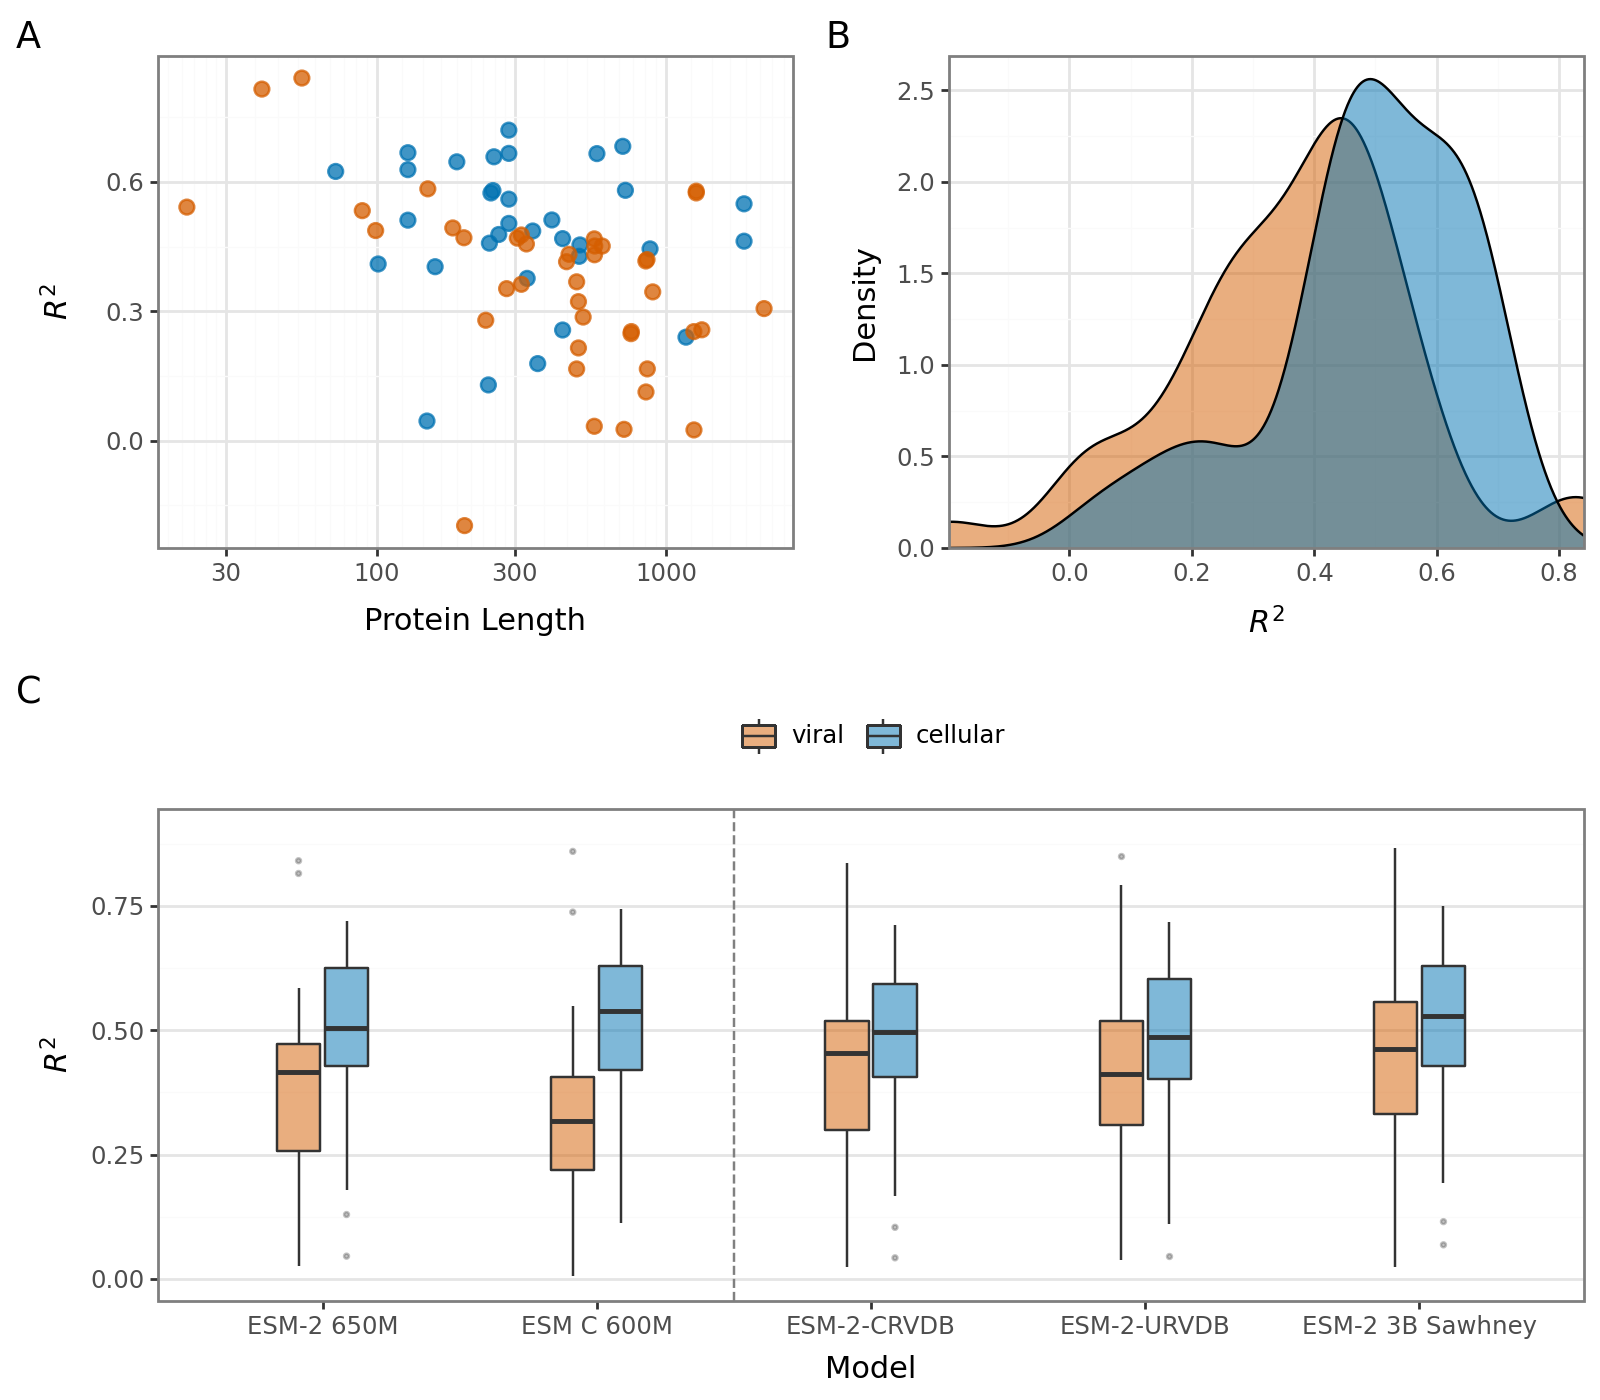

In [ ]:
comp = (p1 | p2) / p3
plot = comp + pln.theme(figure_size=(8, 7.))
plot.save(filename='../experiments/figures/comp1_pLMs_res.png', dpi=600)
plot

# Lasso results all models

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 8 x 5 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: ../experiments/figures/fig4_site_x_random_all_models.png


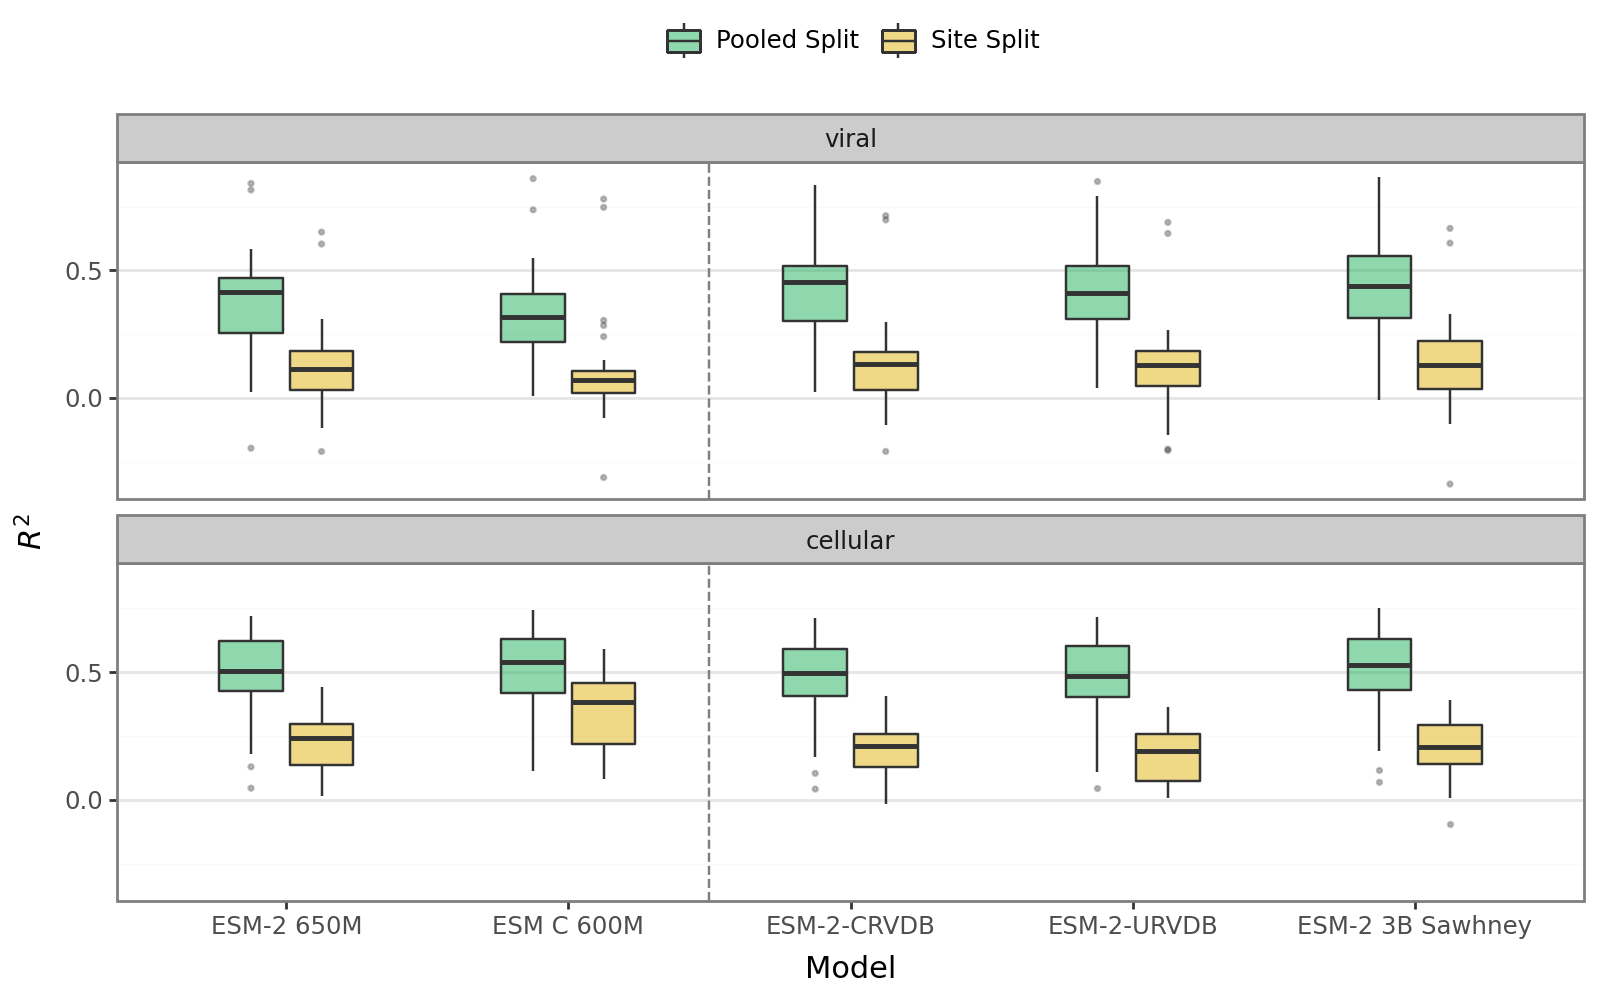

In [38]:
plot = (
    pln.ggplot(res_full, pln.aes(fill='Split', y='R2_score_test', x='Model'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5, alpha=0.5 )
    + pln.geom_vline(xintercept=2.5, linetype='dashed', color='gray', size=0.5)
    + pln.scale_fill_manual(values={"Pooled Split": "#20B15C", "Site Split": "#E2B40E"})
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.facet_wrap('~Source', nrow=2)
    + pln.theme(
        figure_size=(8, 5),
        panel_grid_major_x=pln.element_blank(),
        legend_position='top',
        legend_title=pln.element_blank()
    )
)

plot.save(filename='../experiments/figures/fig4_site_x_random_all_models.png', dpi=600)
plot

In [37]:
full_res.groupby(['Model', 'Split'], as_index=False)['R2_score_test'].mean() 

/tmp/ipykernel_2267237/1555157308.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Model,Split,R2_score_test
0,ESM-2 650M,Pooled Split,0.419492
1,ESM-2 650M,Site Split,0.164085
2,ESM C 600M,Pooled Split,0.404871
3,ESM C 600M,Site Split,0.208900
4,ESM-2-CRVDB,Pooled Split,0.433579
5,ESM-2-CRVDB,Site Split,0.160780
6,ESM-2-URVDB,Pooled Split,0.433359
7,ESM-2-URVDB,Site Split,0.151623
8,ESM-2 3B Sawhney,Pooled Split,0.462026
9,ESM-2 3B Sawhney,Site Split,0.168587


# ESMC

In [39]:
res_esmc = lassocv.query('Model == "ESM C 600M"').copy()
res_esmc['Source'] = pd.Categorical(res_esmc['Source'], categories=['viral', 'cellular'])
res_esmc['prot_length'] = res_esmc['Dataset'].map(prot_lengths)
res_esmc

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,prot_length
0,ESM C 600M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.544940,0.502568,0.674223,0.763363,0.476794,0.532886,0.723885,0.730510,301.6,346
1,ESM C 600M,cellular,AMIE_PSEAE_Whitehead,Site Split,0.382721,0.598540,0.790733,0.630565,0.254229,0.631912,0.834631,0.507805,58.4,346
2,ESM C 600M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.473849,0.583160,0.724281,0.703427,0.420559,0.613820,0.765567,0.667434,335.6,439
3,ESM C 600M,cellular,B3VI55_LIPSTSTABLE,Site Split,0.319779,0.669790,0.824618,0.593023,0.236757,0.708520,0.872100,0.514334,54.4,439
4,ESM C 600M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.303514,0.633591,0.835410,0.527946,0.231265,0.664253,0.872660,0.464384,411.0,439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,ESM C 600M,viral,SARS2_RBD_binding_Starr,Site Split,0.254529,0.644281,0.860842,0.396774,0.004149,0.735969,0.985781,0.202757,31.0,1273
144,ESM C 600M,viral,SARS2_RBD_expression_Starr,Pooled Split,0.569554,0.533033,0.656195,0.741974,0.462231,0.591231,0.731633,0.659764,227.8,1273
145,ESM C 600M,viral,SARS2_RBD_expression_Starr,Site Split,0.152463,0.793739,0.914453,0.364538,0.105449,0.833944,0.962157,0.330291,18.0,1273
146,ESM C 600M,viral,SARS2_XBB15_RBD_Taylor,Pooled Split,0.461458,0.572302,0.735717,0.590936,0.297189,0.638254,0.827776,0.507556,267.2,201


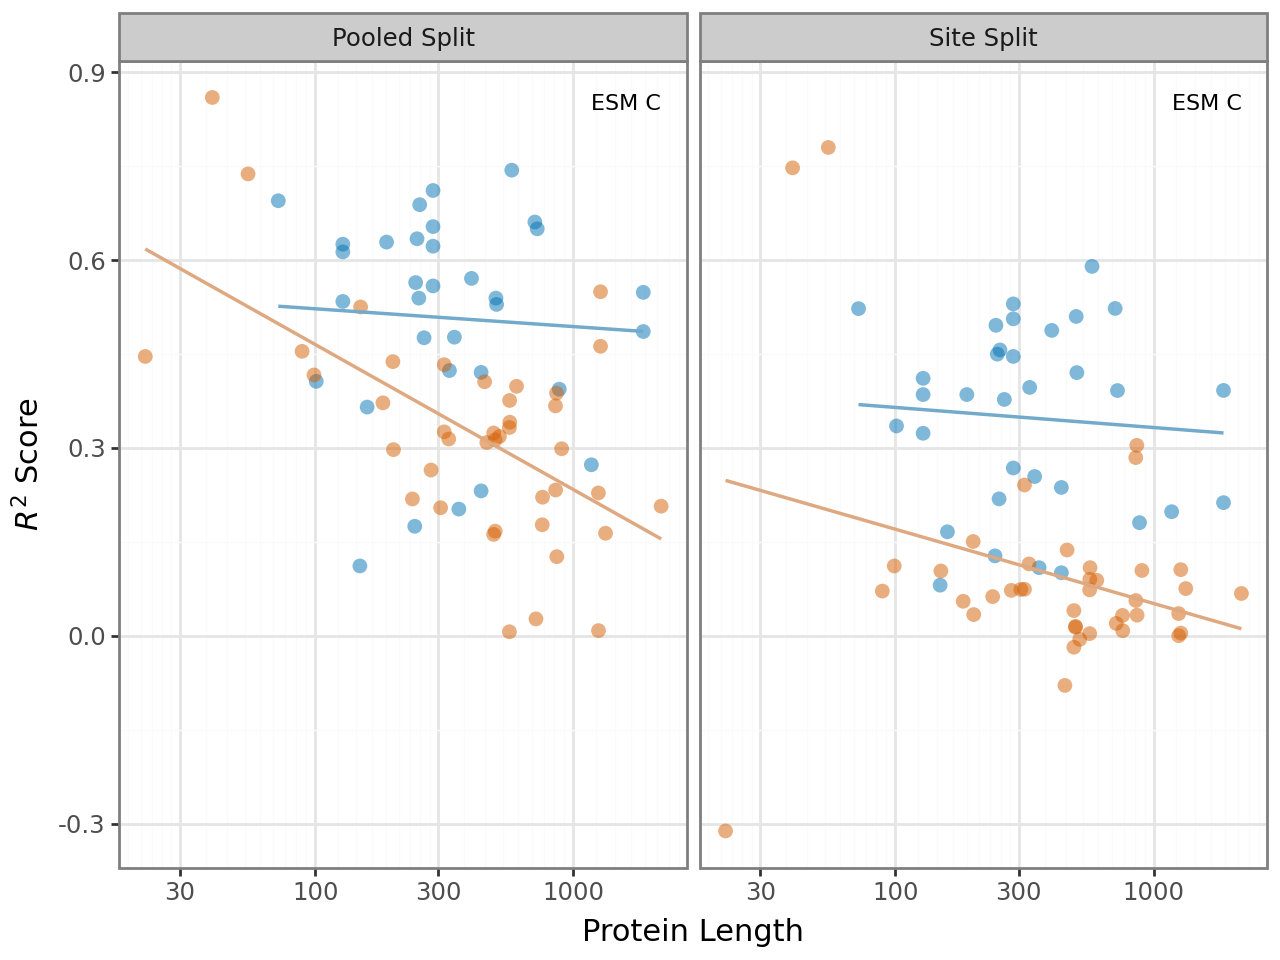

In [76]:
p1 =(
    pln.ggplot(res_esmc, pln.aes(x='prot_length', y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.facet_wrap('Split')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score")
    + pln.theme_bw()
    + pln.annotate('text', x=1600, y=0.85, label='ESM C', size=8)
    + pln.theme(legend_position='none',legend_title=pln.element_blank())

)
p1

In [42]:
res_esm2_3b = lassocv.query('Model == "ESM-2 3B Sawhney"').copy()
res_esm2_3b['Source'] = pd.Categorical(res_esm2_3b['Source'], categories=['viral', 'cellular'])
res_esm2_3b['prot_length'] = res_esm2_3b['Dataset'].map(prot_lengths)
res_esm2_3b

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_test,num_nonzero_coefs,prot_length
148,ESM-2 3B Sawhney,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.686110,0.404638,0.559949,0.846561,0.540731,0.479769,0.678163,0.782551,668.6,346
149,ESM-2 3B Sawhney,cellular,AMIE_PSEAE_Whitehead,Site Split,0.403309,0.580839,0.776730,0.692586,0.291618,0.607741,0.813246,0.587421,91.4,346
150,ESM-2 3B Sawhney,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.640283,0.470605,0.598871,0.815413,0.523620,0.541194,0.694118,0.746783,853.6,439
151,ESM-2 3B Sawhney,cellular,B3VI55_LIPSTSTABLE,Site Split,0.412715,0.617472,0.765875,0.687465,0.294382,0.672588,0.838535,0.600786,155.4,439
152,ESM-2 3B Sawhney,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.411669,0.580821,0.767687,0.607645,0.289827,0.635285,0.838742,0.504102,611.2,439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,ESM-2 3B Sawhney,viral,SARS2_RBD_binding_Starr,Site Split,0.054313,0.734229,0.970373,0.163507,-0.011972,0.755615,0.994496,0.112901,6.2,1273
292,ESM-2 3B Sawhney,viral,SARS2_RBD_expression_Starr,Pooled Split,0.839041,0.310069,0.400708,0.901457,0.630294,0.456176,0.605747,0.799842,904.6,1273
293,ESM-2 3B Sawhney,viral,SARS2_RBD_expression_Starr,Site Split,0.071922,0.840083,0.956010,0.307323,0.010355,0.888039,1.011993,0.192261,10.6,1273
294,ESM-2 3B Sawhney,viral,SARS2_XBB15_RBD_Taylor,Pooled Split,0.718336,0.407546,0.531776,0.712759,0.496997,0.527638,0.701184,0.600082,658.8,201


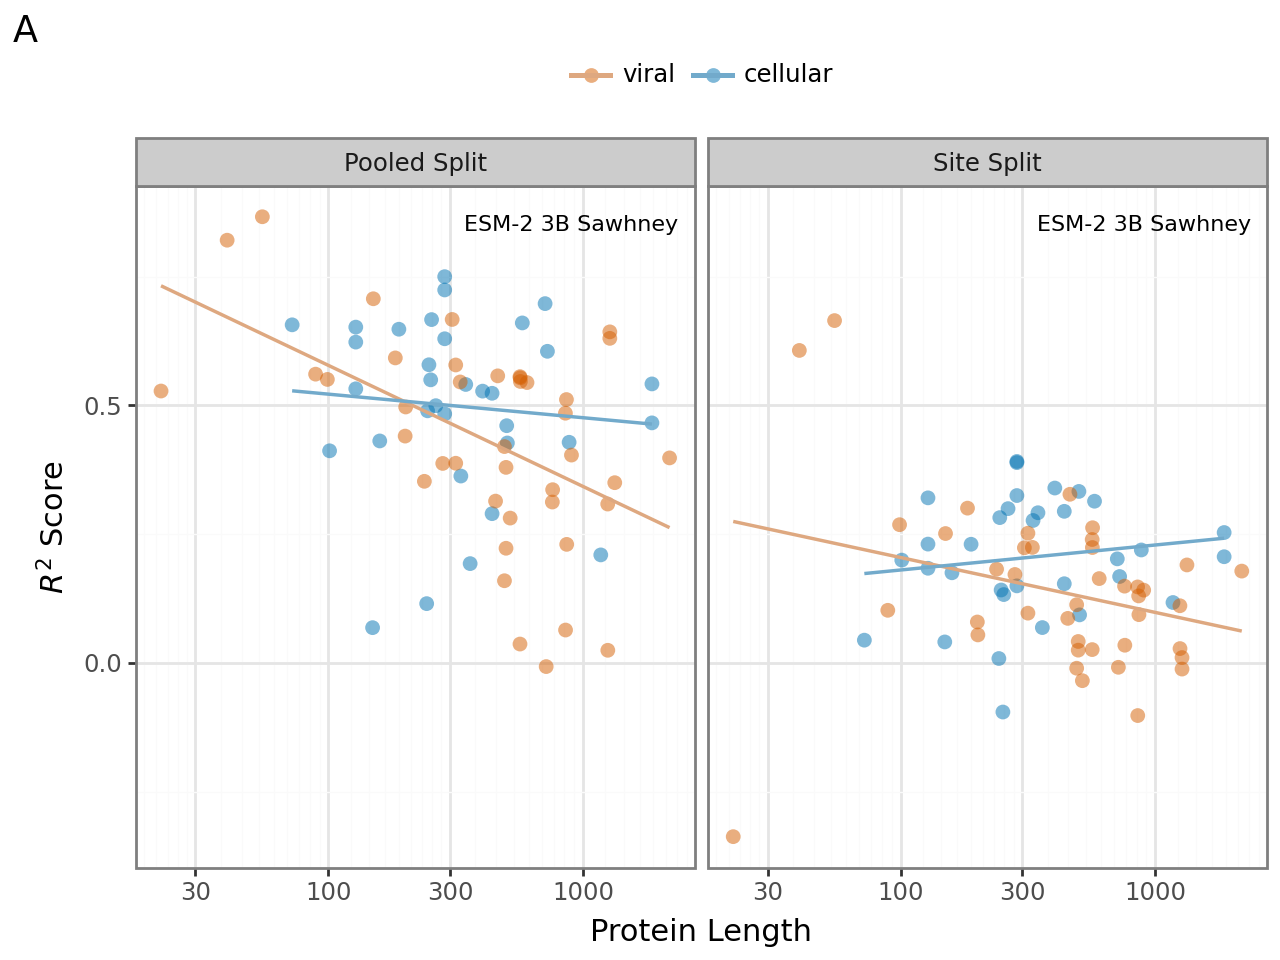

In [74]:
p2 = (
    pln.ggplot(res_esm2_3b, pln.aes(x='prot_length', y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.facet_wrap('Split')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score", tag='A')
    + pln.annotate('text', x=900, y=0.85, label='ESM-2 3B Sawhney', size=8)
    + pln.theme_bw()
    + pln.theme(legend_position='top',legend_title=pln.element_blank())

)
p2

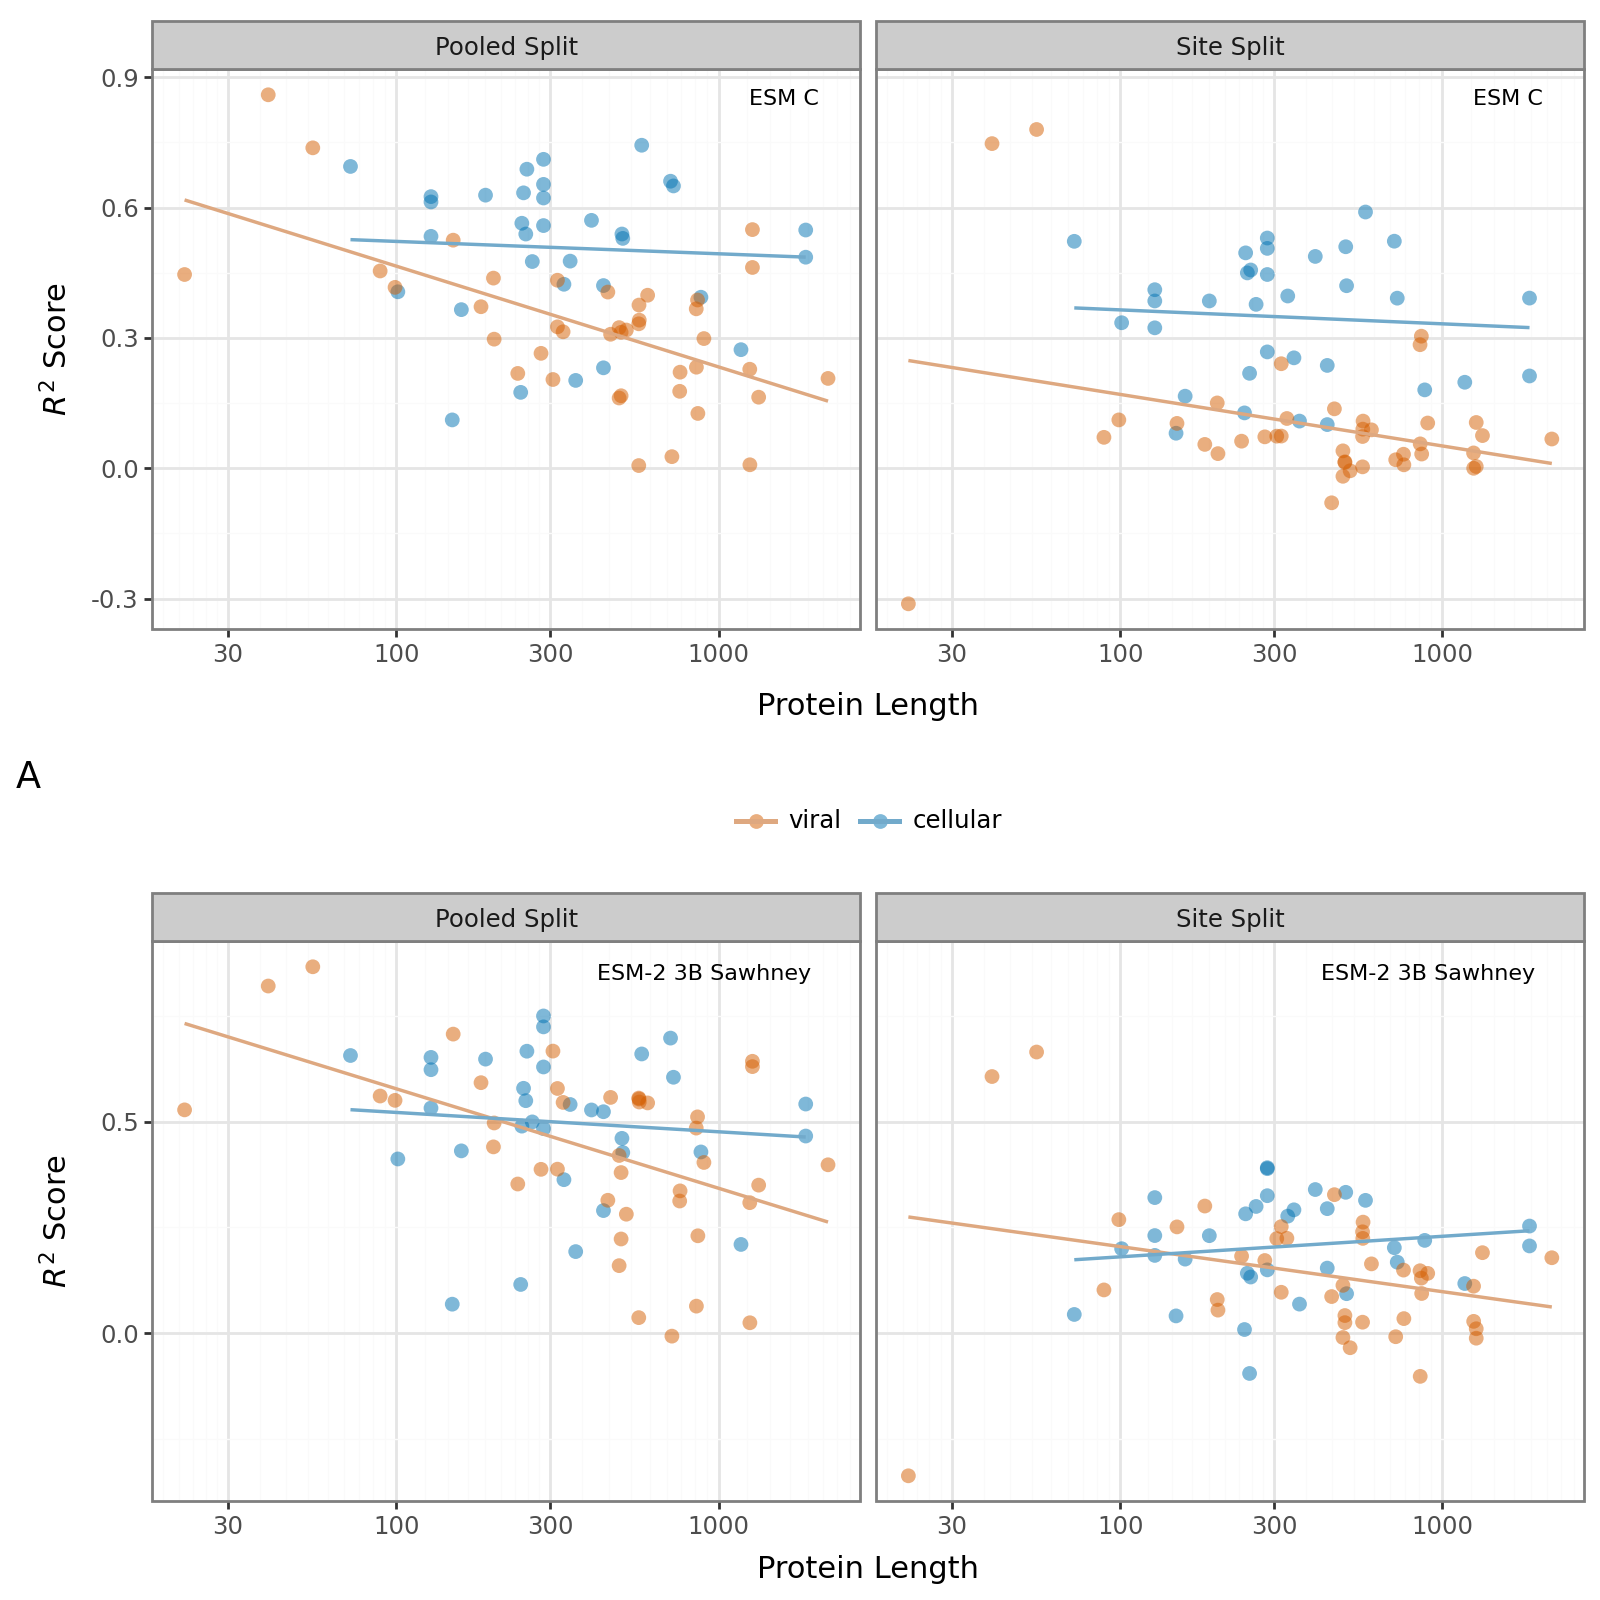

In [78]:
comp = (p1 / p2)
plot = comp + pln.theme(figure_size=(8, 8))
plot.save(filename='../experiments/figures/lassocv_r2_x_prot_length_esmc_esm2-3B.png', dpi=600)
plot